# Iris Species Classification

The data file is about Iris flowers and the goal is to predict the species from measurements. This is a supervised classification problem, since the species is known for each flower, and it is multiclass since several species are possible. The analysis follows a progressive approach, from exploring the data to predicting on a new observation.

## 1. Imports

This consists of importing the packages needed for the whole program.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
pd.set_option("display.precision", 3)

## 2. Loading the data

Loading the data file makes it possible to explore it and prepare the rest of the analysis.

In [ ]:
data = pd.read_csv("/content/sample_data/Iris.csv")

data = data.drop(columns=["Id"])

X = data.drop(columns=["Species"])
y = data["Species"]
species_names = sorted(y.unique())

data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. First look at the dataset

A first review checks the size of the file, the column types and the absence of missing values, before going further in the analysis.

In [ ]:
print("Total number of observations:", data.shape[0])
print("Number of explanatory variables:", X.shape[1])
print("Number of classes to predict:", len(species_names))
print("Classes:", species_names)
print()
data.info()

Total number of observations: 150
Number of explanatory variables: 4
Number of classes to predict: 3
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
data.isnull().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


There are no missing values, and the four variables are continuous and numeric, expressed in centimeters. There is therefore no need for imputation or encoding, the analysis can start directly.

## 4. Descriptive statistics

These statistics give a first idea of the distribution of each variable, through the mean, the spread and the extreme values.

In [ ]:
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


Several things stand out. The variables are not at all on the same scale, since petal length ranges from about 1 to 6.9 cm, while sepal width stays between 2 and 4.4 cm. This matters for models based on distances or margins, notably logistic regression, SVM and KNN, which could otherwise give more weight to variables that simply have larger numeric values. The data will therefore be standardized before training these models.

Another point worth checking is whether the three species are roughly equally represented. If one species dominated the dataset, a model could simply always predict that species and appear to perform well without having really learned anything.

In [ ]:
counts = y.value_counts().reindex(species_names)
counts

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


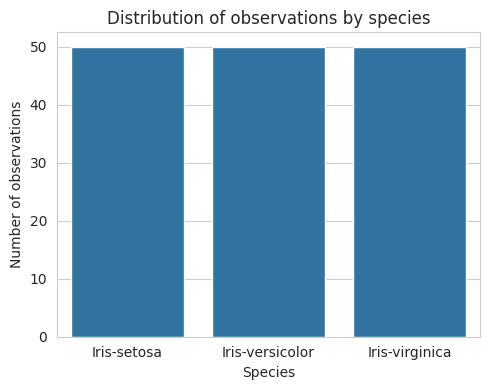

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x=data["Species"], order=species_names)
plt.title("Distribution of observations by species")
plt.xlabel("Species")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

There are exactly 50 observations per species, so the distribution is perfectly balanced. This is convenient, since there is no need to worry about a class imbalance that would distort accuracy as a metric later on.

## 5. Statistics by species

The same statistics are recalculated by grouping them by species, in order to spot the variables that distinguish them best.

In [ ]:
data.groupby("Species").describe().T

Species              Iris-setosa  Iris-versicolor  Iris-virginica
SepalLengthCm count       50.000           50.000          50.000
              mean         5.006            5.936           6.588
              std          0.352            0.516           0.636
              min          4.300            4.900           4.900
              25%          4.800            5.600           6.225
              50%          5.000            5.900           6.500
              75%          5.200            6.300           6.900
              max          5.800            7.000           7.900
SepalWidthCm  count       50.000           50.000          50.000
              mean         3.418            2.770           2.974
              std          0.381            0.314           0.322
              min          2.300            2.000           2.200
              25%          3.125            2.525           2.800
              50%          3.400            2.800           3.000
              75%          3.675            3.000           3.175
              max          4.400            3.400           3.800
PetalLengthCm count       50.000           50.000          50.000
              mean         1.464            4.260           5.552
              std          0.174            0.470           0.552
              min          1.000            3.000           4.500
              25%          1.400            4.000           5.100
              50%          1.500            4.350           5.550
              75%          1.575            4.600           5.875
              max          1.900            5.100           6.900
PetalWidthCm  count       50.000           50.000          50.000
              mean         0.244            1.326           2.026
              std          0.107            0.198           0.275
              min          0.100            1.000           1.400
              25%          0.200            1.200           1.800
              50%          0.200            1.300           2.000
              75%          0.300            1.500           2.300
              max          0.600            1.800           2.500

Petal length and petal width differ clearly between species, with little overlap. Sepal width, on the other hand, has fairly close averages across the three species, so it will likely be less useful for telling them apart.

## 6. Correlations

The correlations between variables are measured here, in order to spot those that carry redundant information.

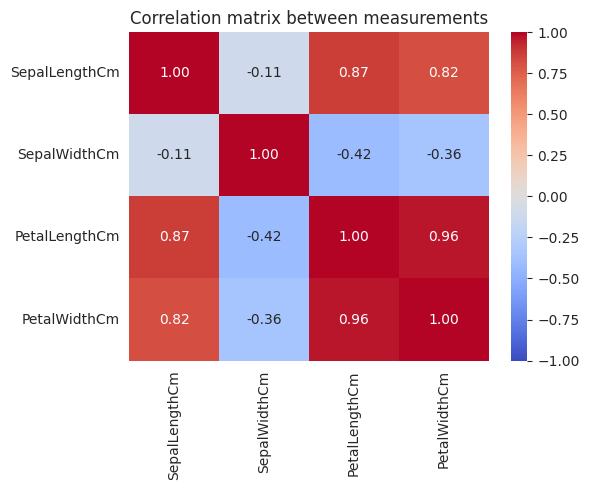

In [ ]:
correlation_matrix = X.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation matrix between measurements")
plt.tight_layout()
plt.show()

Petal length and petal width are very strongly correlated with each other, which makes sense since a larger flower generally has all its dimensions larger, and they are also fairly correlated with sepal length. Sepal width stands apart, remaining weakly correlated with the rest.

## 7. Visualizing separability

A cross visualization of the variables by species makes it easier to judge their separability than plain numbers would.

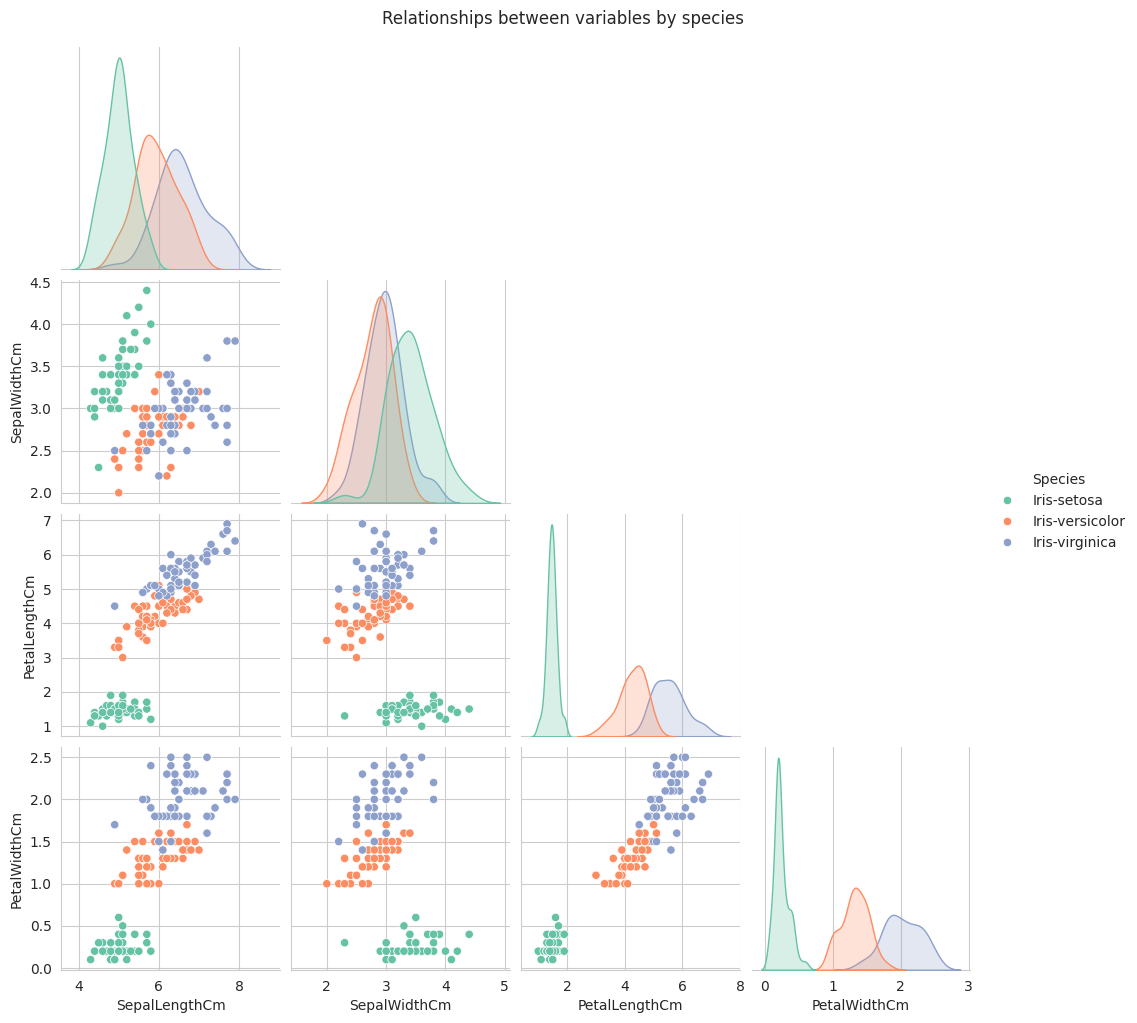

In [ ]:
pairplot = sns.pairplot(data, hue="Species", hue_order=species_names, corner=True, palette="Set2")
pairplot.fig.suptitle("Relationships between variables by species", y=1.02)
plt.show()

This confirms what the statistics already suggested. Setosa is clearly distinct from the other two species, especially on the petal measurements, so it seems easy to separate. Versicolor and virginica overlap more on several plots, so classification errors, if any, should mostly occur between these two species.

## 8. Splitting into training and test data

The data is split into two parts, one to train the model and another set aside to evaluate it on data it has never seen.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## 9. Standardization

All variables are brought here to a comparable scale, so that none dominates simply because its values are larger.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Training the models

Several different classification models are trained here, in order to compare their performance rather than relying on a single arbitrary choice.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy

results_table = pd.Series(results, name="Accuracy").sort_values(ascending=False)
results_table

,Accuracy
Support Vector Machine,0.967
Logistic Regression,0.933
K-Nearest Neighbors,0.933
Random Forest,0.900
Decision Tree,0.900


## 11. Cross validation

The models are re-evaluated here with cross validation, a more reliable method than a single split, in order to confirm the ranking obtained previously.

In [ ]:
cross_val_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cross_val_results[name] = scores.mean()

cross_val_table = pd.Series(cross_val_results, name="Mean cross validation accuracy").sort_values(ascending=False)
cross_val_table

,Mean cross validation accuracy
K-Nearest Neighbors,0.967
Support Vector Machine,0.967
Logistic Regression,0.958
Random Forest,0.950
Decision Tree,0.942


Good news, the cross validation results agree with those obtained on the single split, so the first result was not simply due to a favorable split. The model selected is therefore the one with the best average accuracy in cross validation, since this figure is more reliable than an isolated test score.

In [ ]:
best_model_name = cross_val_table.index[0]
best_model = models[best_model_name]

print("Selected model:", best_model_name)

Selected model: K-Nearest Neighbors


## 12. Detailed look at the best model

The performance of the best model is broken down here by species, since a good overall accuracy can mask weaknesses on a particular class.

In [ ]:
y_pred = best_model.predict(X_test_scaled)

report = classification_report(y_test, y_pred, target_names=species_names)
print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



## 13. Confusion matrix

The confusion matrix shows precisely which species are confused with each other, something the previous metrics could not show directly.

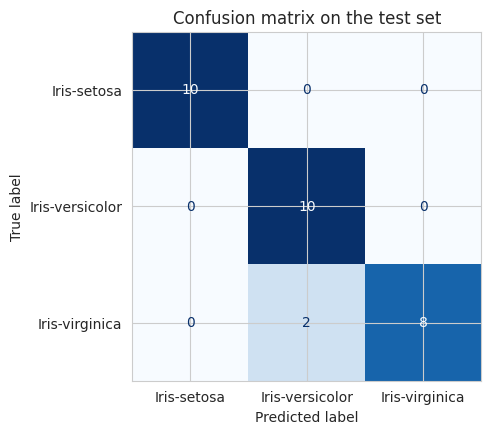

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

Setosa shows no errors at all, which is not surprising given how clearly it separates from the other two. All the errors occur between versicolor and virginica, which matches the overlap observed earlier in the pairplot.

## 14. Feature importance

The goal here is to understand which variables weigh most in the decisions of the selected model, when it allows for it.

In [ ]:
tree_based_models = ["Decision Tree", "Random Forest"]

if best_model_name in tree_based_models:
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(6, 4))
    importances.plot(kind="barh", color="steelblue")
    plt.title("Feature importance in the model's decisions")
    plt.xlabel("Relative importance")
    plt.tight_layout()
    plt.show()
else:
    print("The selected model, " + best_model_name + ", does not directly provide feature importance.")
    print("This type of information is available for tree-based models, such as random forest.")

The selected model, K-Nearest Neighbors, does not directly provide feature importance.
This type of information is available for tree-based models, such as random forest.


## 15. Prediction on a new flower

The trained model is applied here to a new observation, in order to check its use in real conditions.

In [ ]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns,
)

new_flower_scaled = scaler.transform(new_flower)
prediction = best_model.predict(new_flower_scaled)[0]

print("Measurements provided:", new_flower.values.tolist()[0])
print("Predicted species:", prediction)

Measurements provided: [5.1, 3.5, 1.4, 0.2]
Predicted species: Iris-setosa


## Conclusion

The exploratory statistics showed early on that petal length and petal width are the variables that really separate the species, while sepal width contributes little information.

After training and evaluation, accuracy on the test set is high, setosa is identified perfectly every time, and the rare errors occur only between versicolor and virginica, which matches what the pairplot already suggested.

This notebook therefore followed a standard supervised classification approach, namely understanding the data, exploring it through statistics and plots, splitting and standardizing it correctly, comparing several models fairly, validating the choice through cross validation, examining the best model in detail, interpreting it, and then using it to predict on a new observation. The same approach would apply to other classification datasets.